In [25]:
using Pkg
Pkg.activate(".")

using Revise
using LinearAlgebra, SparseArrays
using Random, StatsBase
using Base.Iterators
using DictionaryLearning
import DictionaryLearning.FoldyLax as FL
using Plots, StatsPlots
using Base.Threads, FLoops
using CUDA, Adapt, KernelAbstractions, GPUArrays
using Graphs
using Combinatorics
using KrylovKit
using DataStructures
using JLD2

include("../debug.jl")
;

  Activating project at `~/DictionaryLearning/examples/clustering`


### Settings & Setup

In [26]:
# choose backend
back = :auto
# back = CPU()
# back = CUDABackend()

# auto backend
if back == :auto
    back = CUDA.functional() ? CUDABackend() : CPU()
end

if back == CPU()
    println("$INF using CPU")
elseif back == CUDABackend()
    println("$INF using CUDA")
end

BLAS.set_num_threads(nthreads())

println("# BLAS threads: $(BLAS.get_num_threads())")
println("# Julia threads: $(nthreads())")

[INF] using CUDA
# BLAS threads: 32
# Julia threads: 32


In [ ]:
# ways to form dictionary
function randndict(T::DataType, m::Int, k::Int)
    D = adapt(back, Matrix{T}(undef, m, k))
    randn!(D)
    normalize!.(eachcol(D))
    return D
end

function fldict()
    # see Foldy-Lax example notebook
    @load "../../temp/fl.jld2" G
    G = reshape(G, size(G, 1), :)
    println("$INF size: $(size(G))")
    return adapt(back, G)
end

# construct dictionary
D = randndict(Float64, 20, 30)

# D = randndict(Float64, 20, 30)
# D = ComplexF64.(D)

# D = randndict(ComplexF64, 10, 15)

# D = randndict(Float64, 20, 30)
# D = reinterpret(ComplexF64, D)

# D = fldict()

;

In [28]:

"""
Generate an `k x n` matrix consisting of 
columns with sparsity `s` and with non-zero
entries taking values 1 or -1 uniformally at random.
"""
function gensamples(k::Int, n::Int, s::Int)
    # construct COO format of SparseMatrix
    C = repeat(1:n, inner=[s])
    R = Vector{Int64}(undef, s*n)

    if eltype(D) <: Real
        V = rand(eltype(D), s*n)
        V .= 2 .* V .- 1
    else
        V = rand(Float64, s*n) * (1.0 + 0.0im)
        V .= 2 .* V .- 1

        # V = rand(eltype(D), s*n)
        # V .= 2 .* V .- (1.0 + 1.0im)
    end

    V ./= abs.(V)

    # choose support in each column
    @floop ThreadedEx() for j in 1:n
        @init begin
            rng = MersenneTwister()
            perm = collect(1:k)
        end

        # choose support
        shuffle!(rng, perm)
        sup = view(perm, 1:s)
        copyto!(view(R, s*(j-1)+1:s*j), sup)
    end

    # create sparse matrix
    X = sparse(R, C, V, k, n)

    return adapt(back, X)
end

m, k = size(D)
s = 2 # sparsity of samples
n = 10*m^3 # number of samples
t = 1000 # how many samples to use in recovery
τ = 1.2 # subspace cuttoff

println("$INF m = $m")
println("$INF k = $k")
println("$INF n = $n")
println("$INF t = $t")
println("$INF τ = $τ")
println("$INF type = $(eltype(D))")

# generate samples
X = gensamples(k, n, s)
X_cpu = adapt(CPU(), X)
;

[INF] m = 20
[INF] k = 30
[INF] n = 80000
[INF] t = 1000
[INF] τ = 1.2
[INF] type = ComplexF64


### Dictionary Learning

#### Subspace Recovery

In [29]:
println("$INF approx memory: $((
    (n * (m^2 + t) + m^2*t) * sizeof(eltype(D))
)*1e-9) GB")

if back == CUDABackend()
    println("$INF available CUDA memory: $(CUDA.available_memory()*1e-9)GB")
    println("$INF total CUDA memory: $(CUDA.total_memory()*1e-9)GB")
elseif back == CPU()
    println("$INF available CPU memory: $(Sys.free_memory()()*1e-9)GB")
    println("$INF total CPU memory: $(Sys.total_memory()()*1e-9)GB")
end

[INF] approx memory: 1.7984000000000002 GB
[INF] available CUDA memory: 11.424759808000001GB
[INF] total CUDA memory: 25.386352640000002GB


In [30]:
function subrec()
    # preallocate stuff
    Σ = adapt(back, Matrix{eltype(D)}(undef, m, m))
    G = adapt(back, Matrix{eltype(D)}(undef, n, t))
    V = adapt(back, Matrix{eltype(D)}(undef, n, m^2))
    YT = X'*D'
    Z = adapt(back, Array{eltype(D)}(undef, m, m, t))
    work = adapt(back, Vector{eltype(D)}(undef, max(m^2, k^2 + k*t)))
    S = adapt(back, Array{eltype(D)}(undef, m, s, t))
    St = adapt(back, Array{eltype(D)}(undef, m, s, t))

    println("$INF actual memory: $((
        sizeof(Σ)+sizeof(G)+sizeof(V)+sizeof(YT)+sizeof(Z)+sizeof(work)
        +sizeof(S)+sizeof(St)
    )*1e-9) GB")
    
    # recover subspaces
    println("$STS computing Σ")
    elap = @elapsed begin
       compΣ!(Σ, D, X, work)
    end
    println("$TAB$INF elapsed: $elap s")

    println("$STS computing G")
    elap = @elapsed begin
        compG!(G, D, X, 1:t, work)
    end
    println("$TAB$INF elapsed: $elap s")

    println("$STS computing V")
    elap = @elapsed begin
        compV!(V, YT)
    end
    println("$TAB$INF elapsed: $elap s")

    println("$STS computing Z")
    elap = @elapsed begin
        compZ!(Z, G, V)
    end
    println("$TAB$INF elapsed: $elap s")

    println("$STS computing subspaces")
    elap = @elapsed begin
        compS!(S, Z, Σ, s)
    end
    println("$TAB$INF elapsed: $elap s")

    # true subspaces
    println("$STS computing true subspaces")
    elap = @elapsed begin
        truesubs!(St, D, X_cpu[:,1:t], s)
    end
    println("$TAB$INF elapsed: $elap s")

    return S, St
end

# get approximate/true subspaces
S, St = subrec()

# move back to CPU for clustering
S_cpu = adapt(CPU(), S)
St_cpu = adapt(CPU(), St)

;

[INF] actual memory: 1.8257808000000002 GB
[STS] computing Σ
     [INF] elapsed: 0.000899001 s
[STS] computing G
     [INF] elapsed: 2.232197708 s
[STS] computing V
     [INF] elapsed: 4.6999e-5 s
[STS] computing Z
     [INF] elapsed: 0.000101132 s
[STS] computing subspaces
     [INF] elapsed: 0.540960206 s
[STS] computing true subspaces
     [INF] elapsed: 0.070121813 s


[INF] mean err: 0.3705836301499264


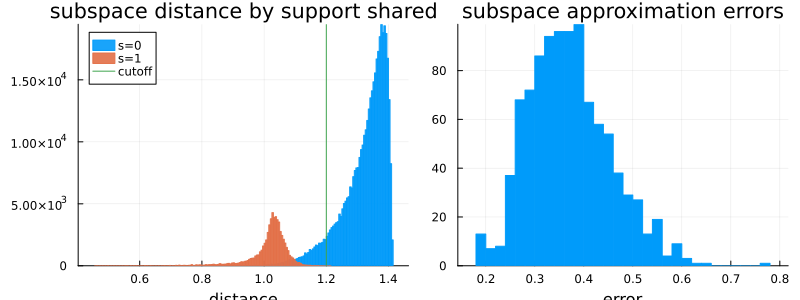

In [31]:
function plot_sd_by_sup(S::AbstractArray, X::AbstractMatrix{T}, s::Int, t::Int) where T
    # the distance between subspaces that share support
        #  of size `n` will be stored in `samps[n]`
    samps = DefaultDict{Int64, Vector{Float64}}(()->Float64[])
    
    # collect all pairs of subspaces
    l1 = Vector{Int}(undef, binomial(t, 2))
    l2 = similar(l1)
    for (i, (j, k)) in enumerate(combinations(1:t,2))
        l1[i] = j
        l2[i] = k
    end

    # pair up subspaces
    X1 = view(X, :, l1)
    X2 = view(X, :, l2)

    S1 = view(S, :, :, l1)
    S2 = view(S, :, :, l2)

    # determine support of each pair
    nss = Vector{Int}(undef, binomial(t, 2))
    nsupshared!(nss, X1, X2)

    # determine subspace distances
    sds = Vector{Float64}(undef, binomial(t, 2))
    subdists!(sds, S1, S2)

    # sort subdists based on support
    for (ss, sd) in zip(nss, sds)
        push!(samps[ss], sd)
    end

    # create plot
    p = Plots.plot(
        title="subspace distance by support shared",
        xlabel="distance"
    )
    for i in 0:s-1
        if length(samps[i]) > 0
            Plots.histogram!(samps[i], label="s=$i", alpha=0.9, linecolor = :match)
        end
    end
    vline!([τ], label="cutoff")

    return p
end

function plot_sd_err(asubs::AbstractArray{T}, tsubs::AbstractArray{T}) where T
    # compute distance from true subspaces
    sd = Vector{Float64}(undef, size(asubs, 3))
    subdists!(sd, tsubs, asubs)
    println("$INF mean err: $(mean(sd))")

    p = Plots.histogram(
        sd, 
        title="subspace approximation errors", 
        xlabel="error",
        legend=false,
        linecolor = :match
    )
    
    return p
end

p1 = plot_sd_by_sup(S_cpu, X_cpu, s, t)
p2 = plot_sd_err(S_cpu, St_cpu)
plot(p1, p2, size = (800, 300))

#### Clustering

In [32]:
# function getrecdics()
#     println("$INF forming graphs")
#     g = formgraph(S_cpu, τ)
#     gt = truetruegraph(X_cpu, t, s)

#     negdiff = nedgedif(g, gt)
#     neg = ne(g)
#     println("$TAB$INF # total edges: $(neg)")
#     println("$TAB$INF # edges different: $(negdiff)")
#     println("$TAB$INF % edges different: $(100*negdiff/neg)%")

#     Dr = similar(D)
#     Drt = similar(D)

#     println("$STS clustering from approx.")
#     elap = @elapsed begin
#         simps = cluster(g, k, s, back)
#     end
#     println("$TAB$INF elapsed: $elap s")

#     println("$STS recovering from approx.")
#     elap = @elapsed begin
#         recdict!(Dr, S, simps)
#     end
#     println("$TAB$INF elapsed: $elap s")

#     println("$STS clustering true")
#     elap = @elapsed begin
#         simpst = cluster(gt, k, s, back)
#     end
#     println("$TAB$INF elapsed: $elap s")

#     println("$STS recovering from approx.")
#     elap = @elapsed begin
#         recdict!(Drt, S, simpst)
#     end
#     println("$TAB$INF elapsed: $elap s")

#     return Dr, Drt
# end

# Dr, Drt = getrecdics()

# p = Plots.plot()

# err = adapt(CPU(), maximum(abs.(D'*Drt), dims=2))
# StatsPlots.dotplot!(err, alpha=0.9, label="true graph", normalize=:probability)

# err = adapt(CPU(), maximum(abs.(D'*Dr), dims=2))
# StatsPlots.dotplot!(err, alpha=0.9, label="approx. graph", normalize=:probability)

# p